# Hello Sorbetto!

Sorbetto is an open-source library designed for anyone who wants to analyze and
compare the performances of entities (methods, techniques, models, algorithms,
etc.) for tasks similar to two-class crisp (ie, hard or binary) classification.
In the near future, we plan to extend Sorbetto to other tasks. Let us give a few
examples of two-class crisp classification.

**Example 1.** In medicine, when deciding whether a patient has a given disease
or not, it is a two-class crisp classification problem with the classes
"without the disease" and "with the disease".

**Example 2.** In daily lives, when deciding whether an emal is a spam or not,
it is a two-class crisp classification problem.

**Example 3.** In surveillance systems, when deciding whether some change
happend or not, it is a two-class crisp classification problem.

Sorbetto implements modern tools, based on solid theoretical foundations, which
allow results to be put into perspective of preferences related to the targeted
application or to the end user.

This tutorial will guide you through installing the library, and plotting your
very first Tile.


## Install

If you have not done so yet, you can install Sorbetto in your Python environment
by following our official [installation
instructions](https://sorbetto.readthedocs.io/en/latest/install.html).


## My very first *Tile*

The *Tile* is a 2D graphical tool designed to depict information about
classifciations with respect to some preferences:
- the relative importance of the true positives with respect to the true
  negatives on the horizontal axis;
- the relative importance of the false negatives with respect to the false
  positives on the vertical axis.

Our very first *Tile* shows this space.

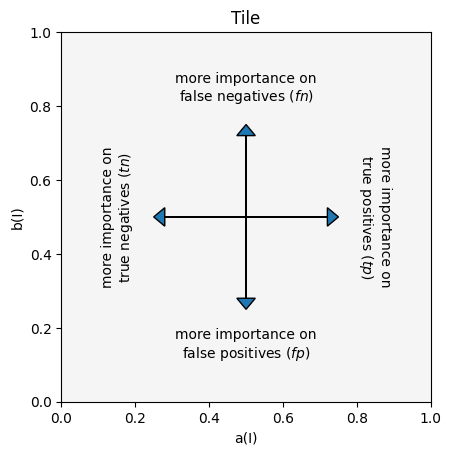

In [1]:
from sorbetto.annotation import AnnotationImportanceCompass
from sorbetto.parameterization import ParameterizationDefault
from sorbetto.tile import Tile

parameterization = ParameterizationDefault()
tile = Tile(parameterization)
tile.appendAnnotation(AnnotationImportanceCompass())
tile.draw();

## What are the strengths and weaknesses of my method?

Let's see how we can define a performance (ie, the four elements of the
normalized confusion matrix) and compute the values taken by a few scores that
are well suited for ranking.

In [2]:
from sorbetto.performance import TwoClassClassificationPerformance
from sorbetto.ranking import RankingScore

# Encode here the performance of your method
# These should be four positive values summing up to one.
my_ptn = 0.5  # the probability of a true negative
my_pfp = 0.2  # the probability of a false positive
my_pfn = 0.1  # the probability of a false negative
my_ptp = 0.2  # the probability of a true positive
my_performance = TwoClassClassificationPerformance(my_ptn, my_pfp, my_pfn, my_ptp)

# What scores do I like?
scores = [
    RankingScore.getAccuracy(),
    RankingScore.getSensitivity(),
    RankingScore.getSpecificity(),
    RankingScore.getSelectivity(),
    RankingScore.getPrecision(),
    RankingScore.getRecall(),
]

for score in scores:
    print("\t", score.longLabel, "=", score(my_performance))

	 Accuracy (A) = 0.7
	 Sensitivity = 0.6666666666666666
	 Specificity (Sp) = 0.7142857142857143
	 Selectivity = 0.7142857142857143
	 Precision (Pr) = 0.5
	 Recall (Re) = 0.6666666666666666


Now, let's draw a Tile for that.

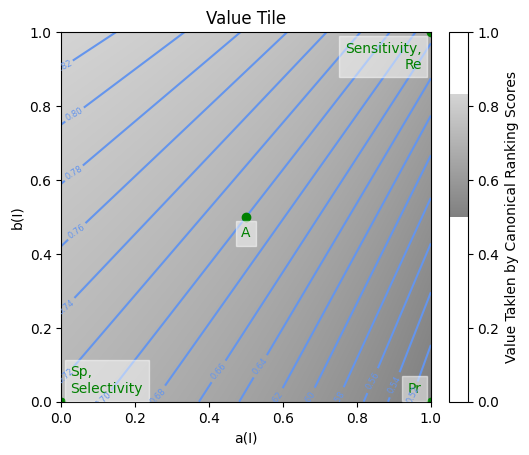

In [3]:
from sorbetto.annotation import AnnotationIsovalueCurves, AnnotationText
from sorbetto.flavor import ValueFlavor
from sorbetto.parameterization import ParameterizationDefault
from sorbetto.tile import ValueTile

flavor = ValueFlavor(my_performance, "Value Taklen by Canonical Ranking Scores")
parameterization = ParameterizationDefault()
tile = ValueTile(parameterization, flavor)
tile.appendAnnotation(AnnotationIsovalueCurves())
for score in scores:
    tile.appendAnnotation(AnnotationText(score, color="green"))
tile.draw();

We see that the value taken by the scores that are on the *Tile* (the continuum
of *canonical ranking scores*) is between $0.4$ and $0.8$. 

The weakness of my method is in the bottom-right corner of the *Tile*: it is for
applications or users that put much more importance to the true positives than
to the true negatives, and that put much more importance to the false positives
than to the false negatives.

The strength of my method is in the upper-left corner of the *Tile*: it is for
applications or users that put much more importance to the true negatives than
to the true positives, and that put much more importance to the false negatives
than to the false positives.

## How does my method compare to no-skill classifiers?

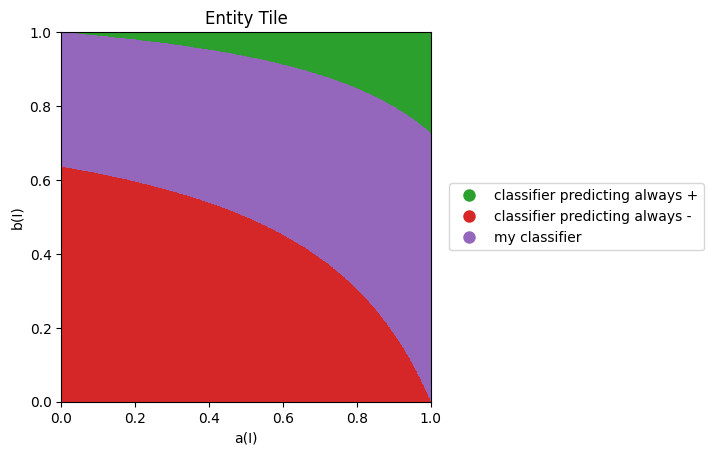

In [4]:
from sorbetto.flavor import EntityFlavor
from sorbetto.ranking import Entity
from sorbetto.tile import EntityTile

# What is the prior of the positive class?
priorPos = my_pfn + my_ptp

# The performance of the classifier predicting always the negative class
p0 = TwoClassClassificationPerformance.getNoSkill(priorPos=priorPos, ratePos=0.0)
# The performance of the classifier predicting always the positive class
p1 = TwoClassClassificationPerformance.getNoSkill(priorPos=priorPos, ratePos=1.0)

entities = [
    Entity(my_performance, "my classifier", color="tab:purple"),
    Entity(p0, "classifier predicting always -", color="tab:red"),
    Entity(p1, "classifier predicting always +", color="tab:green"),
]
parameterization = ParameterizationDefault()
flavor = EntityFlavor(1, entities)  # Who's ranked first?
tile = EntityTile(parameterization, flavor)
tile.draw();

As we see, my classifier is performing better than the no-skill classifiers
(e.g., those predicting always the same class, in red or green) only in a "small
band" of importances (in purple). My classifier does not bring anything to the
users having their application-related preferences out of this band.

## What rank do I expect to reach with my classifier in a competition ?

ERROR:root:
Traceback (most recent call last):
  File "/home/mfrancois/workspace/sorbetto/sorbetto/tile/_numeric_tile.py", line 258, in draw
    _, _, minimized_value = self.minimize()
                            ~~~~~~~~~~~~~^^
  File "/home/mfrancois/workspace/sorbetto/sorbetto/tile/_numeric_tile.py", line 156, in minimize
    return self._optimize(1.0, precision)
           ~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^
  File "/home/mfrancois/workspace/sorbetto/sorbetto/tile/_numeric_tile.py", line 138, in _optimize
    assert isinstance(v, float)
           ~~~~~~~~~~^^^^^^^^^^
AssertionError


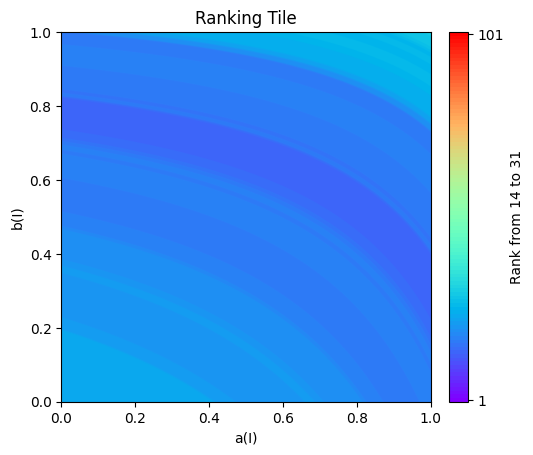

In [5]:
from sorbetto.flavor import RankingFlavor
from sorbetto.performance_distribution import (
    UniformDistributionOfTwoClassClassificationPerformancesForFixedClassPriors,
)
from sorbetto.tile import RankingTile

# Let us choose a number of competitors
num_competitors = 100

# Let us choose some reference distribution of performances
distribution = (
    UniformDistributionOfTwoClassClassificationPerformancesForFixedClassPriors(priorPos)
)

all_entities = list()
my_classifier = Entity(my_performance, "my classifier")
all_entities.append(my_classifier)
for i, performance in enumerate(distribution.drawAtRandom(num_competitors)):
    competitor = Entity(performance, "competitor {}".format(i))
    all_entities.append(competitor)

parameterization = ParameterizationDefault()
flavor = RankingFlavor(my_classifier, all_entities)
tile = RankingTile(parameterization, flavor)
tile.draw();

In [6]:
message = (
    "With these {} randomly generated virtual competitors, "
    "my rank is between {} and {} depending on the importances."
)
print(message.format(num_competitors, tile.min, tile.max))

With these 100 randomly generated virtual competitors, my rank is between 14 and 31 depending on the importances.
